In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("Road.csv", na_values=["na","NA","Na","N/A","","NaN"])



In [4]:
df.head(10)

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3.0,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3.0,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
5,14:15:00,Friday,31-50,Male,NaN,Unknown,NaN,NaN,NaN,NaN,...,U-Turn,Driver or rider,Male,31-50,3.0,Driver,Normal,Not a Pedestrian,Overloading,Slight Injury
6,17:30:00,Wednesday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,NaN,...,Moving Backward,Driver or rider,Female,18-30,3.0,Driver,Normal,Not a Pedestrian,Other,Slight Injury
7,17:20:00,Friday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Governmental,Above 10yr,...,U-Turn,NaN,NaN,NaN,NaN,NaN,Normal,Not a Pedestrian,No priority to vehicle,Slight Injury
8,17:20:00,Friday,18-30,Male,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,1-2yr,...,Going straight,Pedestrian,Male,Under 18,3.0,Driver,Normal,Crossing from driver's nearside,Changing lane to the right,Slight Injury
9,17:20:00,Friday,18-30,Male,Junior high school,Employee,1-2yr,Automobile,Owner,2-5yrs,...,U-Turn,Passenger,Male,18-30,3.0,Driver,Normal,Not a Pedestrian,Moving Backward,Serious Injury


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Time                         12316 non-null  str    
 1   Day_of_week                  12316 non-null  str    
 2   Age_band_of_driver           12316 non-null  str    
 3   Sex_of_driver                12316 non-null  str    
 4   Educational_level            11575 non-null  str    
 5   Vehicle_driver_relation      11737 non-null  str    
 6   Driving_experience           11487 non-null  str    
 7   Type_of_vehicle              11366 non-null  str    
 8   Owner_of_vehicle             11834 non-null  str    
 9   Service_year_of_vehicle      8388 non-null   str    
 10  Defect_of_vehicle            7889 non-null   str    
 11  Area_accident_occured        12077 non-null  str    
 12  Lanes_or_Medians             11931 non-null  str    
 13  Road_allignment            

In [6]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                 4443
Sex_of_casualty                4443
Age_band_of_casualty           4443
Casualty_severity              4443
Work_of_casuality           

In [7]:
df.drop("Service_year_of_vehicle",axis=1,inplace=True)
df.drop("Defect_of_vehicle",axis=1,inplace=True)


In [8]:
df.reset_index(drop=True, inplace=True)

In [9]:
for col in df.columns:
    if df[col].dtype=='object' or df[col].dtype=='str':
        df[col]=df[col].fillna(df[col].mode()[0])
    elif df[col].dtype == 'float64' :
          df[col]=df[col].fillna(df[col].mean())

In [10]:
print(df["Type_of_vehicle"].unique())

<ArrowStringArray>
[          'Automobile',  'Public (> 45 seats)',      'Lorry (41?100Q)',
 'Public (13?45 seats)',       'Lorry (11?40Q)',           'Long lorry',
    'Public (12 seats)',                 'Taxi',     'Pick up upto 10Q',
         'Stationwagen',         'Ridden horse',                'Other',
                'Bajaj',                'Turbo',           'Motorcycle',
      'Special vehicle',              'Bicycle']
Length: 17, dtype: str


In [11]:
df["Type_of_vehicle"]= df["Type_of_vehicle"].replace({"Lorry (41?100Q)":"Lorry (41-100Q)","Lorry (11?40Q)":"Lorry (11-40Q)",
                                                      "Public (13?45 seats)":"Public (13-45 seats)"})

In [12]:
print(df["Type_of_vehicle"].unique())

<ArrowStringArray>
[          'Automobile',  'Public (> 45 seats)',      'Lorry (41-100Q)',
 'Public (13-45 seats)',       'Lorry (11-40Q)',           'Long lorry',
    'Public (12 seats)',                 'Taxi',     'Pick up upto 10Q',
         'Stationwagen',         'Ridden horse',                'Other',
                'Bajaj',                'Turbo',           'Motorcycle',
      'Special vehicle',              'Bicycle']
Length: 17, dtype: str


In [13]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates:\n{df.shape}")

Shape after removing duplicates:
(12316, 30)


In [14]:
df["Time"]= pd.to_datetime(df['Time'],format='%H:%M:%S').dt.time

In [15]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties,Casualty_severity
count,12316.000000,12316.000000,12316.000000
mean,2.040679,1.548149,2.895466
std,0.688790,1.007179,0.253112
min,1.000000,1.000000,1.000000
25%,2.000000,1.000000,2.895466
50%,2.000000,1.000000,3.000000
75%,2.000000,2.000000,3.000000
max,7.000000,8.000000,3.000000


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Time                         12316 non-null  object 
 1   Day_of_week                  12316 non-null  str    
 2   Age_band_of_driver           12316 non-null  str    
 3   Sex_of_driver                12316 non-null  str    
 4   Educational_level            12316 non-null  str    
 5   Vehicle_driver_relation      12316 non-null  str    
 6   Driving_experience           12316 non-null  str    
 7   Type_of_vehicle              12316 non-null  str    
 8   Owner_of_vehicle             12316 non-null  str    
 9   Area_accident_occured        12316 non-null  str    
 10  Lanes_or_Medians             12316 non-null  str    
 11  Road_allignment              12316 non-null  str    
 12  Types_of_Junction            12316 non-null  str    
 13  Road_surface_type          

In [17]:
df.isnull().sum()

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian_movement            0
Cause_of_accident              0
Accident_severity              0
dtype: int

In [18]:
df.to_csv("Road_cleaned.csv",index=False)

In [19]:
df.head(10)

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Residential areas,...,Going straight,Driver or rider,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,Office areas,...,Going straight,Driver or rider,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41-100Q),Owner,Recreational areas,...,Going straight,Driver or rider,Male,31-50,3.000000,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Office areas,...,Going straight,Pedestrian,Female,18-30,3.000000,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,Industrial areas,...,Going straight,Driver or rider,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury
5,14:15:00,Friday,31-50,Male,Junior high school,Unknown,5-10yr,Automobile,Owner,Other,...,U-Turn,Driver or rider,Male,31-50,3.000000,Driver,Normal,Not a Pedestrian,Overloading,Slight Injury
6,17:30:00,Wednesday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,Residential areas,...,Moving Backward,Driver or rider,Female,18-30,3.000000,Driver,Normal,Not a Pedestrian,Other,Slight Injury
7,17:20:00,Friday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Governmental,Residential areas,...,U-Turn,Driver or rider,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,No priority to vehicle,Slight Injury
8,17:20:00,Friday,18-30,Male,Junior high school,Employee,Above 10yr,Lorry (41-100Q),Owner,Industrial areas,...,Going straight,Pedestrian,Male,Under 18,3.000000,Driver,Normal,Crossing from driver's nearside,Changing lane to the right,Slight Injury
9,17:20:00,Friday,18-30,Male,Junior high school,Employee,1-2yr,Automobile,Owner,Residential areas,...,U-Turn,Passenger,Male,18-30,3.000000,Driver,Normal,Not a Pedestrian,Moving Backward,Serious Injury


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
 
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Residential areas,...,Going straight,Driver or rider,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,Office areas,...,Going straight,Driver or rider,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41-100Q),Owner,Recreational areas,...,Going straight,Driver or rider,Male,31-50,3.000000,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Office areas,...,Going straight,Pedestrian,Female,18-30,3.000000,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,Industrial areas,...,Going straight,Driver or rider,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury


In [21]:
df["hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce").dt.hour

def bucket(h):
    if h < 4: 
        return "12-4am"
    elif h < 8: 
        return "4-8am"
    elif h < 12: 
        return "8-12pm"
    elif h < 16: 
        return "12-4pm"
    elif h < 20: 
        return "4-8pm"
    else:
         return "8-12am"

df["time_bucket"] = df["hour"].apply(bucket)
time_order = ["12-4am", "4-8am", "8-12pm", "12-4pm", "4-8pm", "8-12am"]

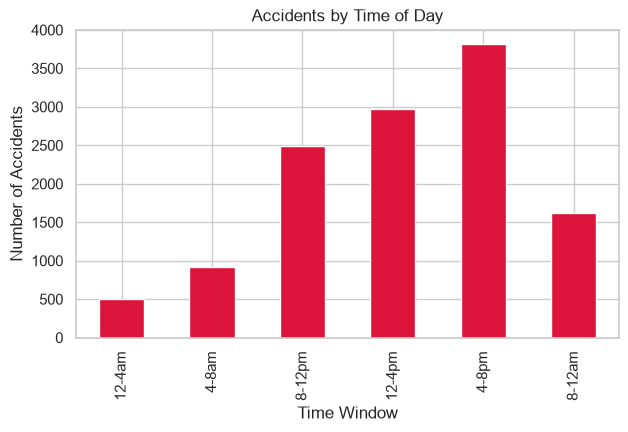

In [22]:
plt.figure(figsize=(7,4))
df["time_bucket"].value_counts().reindex(time_order).plot(kind="bar", color="crimson")
plt.title("Accidents by Time of Day")
plt.xlabel("Time Window")
plt.ylabel("Number of Accidents")
plt.show()

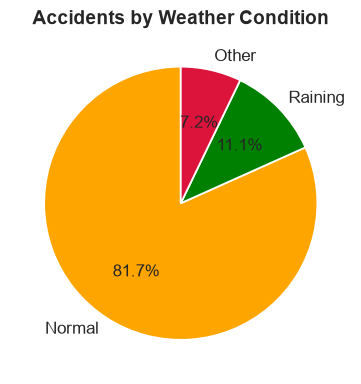

In [23]:
# Group weather conditions into 3 clean categories
def group_weather(w):
    if w == "Normal":
        return "Normal"
    elif w in ["Raining", "Raining and Windy"]:
        return "Raining"
    else:
        return "Other"

weather_grouped = df["Weather_conditions"].apply(group_weather).value_counts()

plt.figure(figsize=(6,4))
colors = ["orange", "green", "crimson"]
plt.pie(
    weather_grouped.values,
    labels=weather_grouped.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.3},
    textprops={"fontsize": 12}
)
plt.title("Accidents by Weather Condition", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

C:\Users\akshi\AppData\Local\Temp\ipykernel_30588\4215800042.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Type_of_vehicle", data=df, order=df["Type_of_vehicle"].value_counts().index[:8], palette="Reds_r")


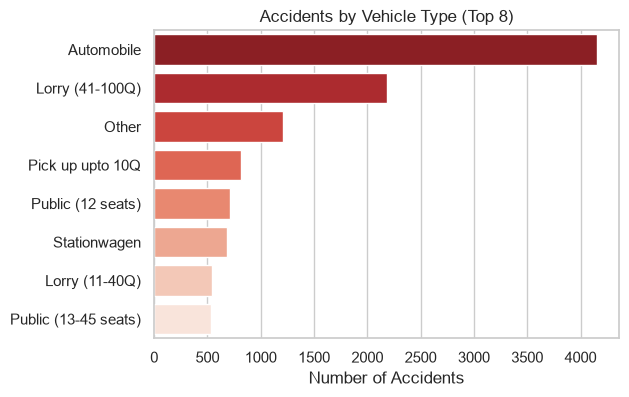

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(y="Type_of_vehicle", data=df, order=df["Type_of_vehicle"].value_counts().index[:8], palette="Reds_r")
plt.title("Accidents by Vehicle Type (Top 8)")
plt.xlabel("Number of Accidents")
plt.ylabel("")
plt.show()

C:\Users\akshi\AppData\Local\Temp\ipykernel_30588\1606260227.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Day_of_week", data=df, order=day_order, palette="RdPu")


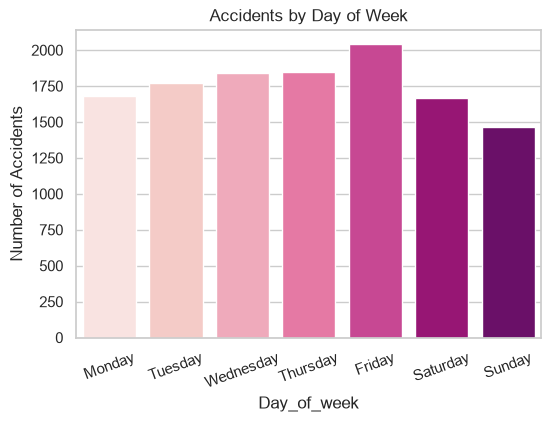

In [25]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

plt.figure(figsize=(6,4))
sns.countplot(x="Day_of_week", data=df, order=day_order, palette="RdPu")
plt.title("Accidents by Day of Week")
plt.xticks(rotation=20)
plt.ylabel("Number of Accidents")
plt.show()

C:\Users\akshi\AppData\Local\Temp\ipykernel_30588\4042480130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_causes.values, y=top_causes.index, palette="Reds_r")


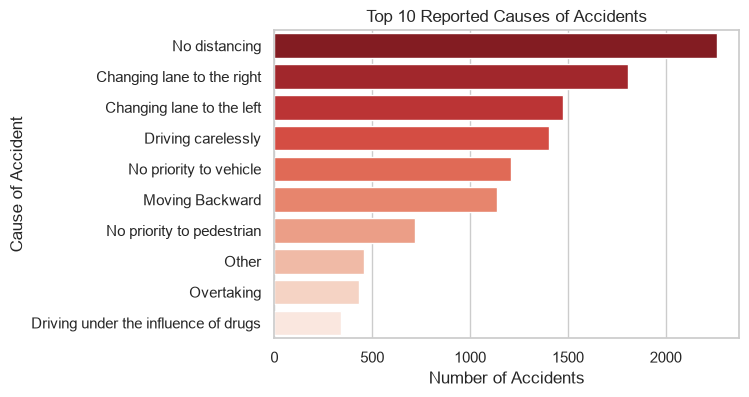

In [26]:
plt.figure(figsize=(6,4))
top_causes = df["Cause_of_accident"].value_counts().head(10)
sns.barplot(x=top_causes.values, y=top_causes.index, palette="Reds_r")
plt.title("Top 10 Reported Causes of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Cause of Accident")
plt.show()

In [27]:
df.head()


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,...,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,hour,time_bucket
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Residential areas,...,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,Moving Backward,Slight Injury,17,4-8pm
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,Office areas,...,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury,17,4-8pm
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41-100Q),Owner,Recreational areas,...,Male,31-50,3.000000,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury,17,4-8pm
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Office areas,...,Female,18-30,3.000000,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1,12-4am
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,Industrial areas,...,Male,18-30,2.895466,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury,1,12-4am


C:\Users\akshi\AppData\Local\Temp\ipykernel_30588\1428789034.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x="Area_accident_occured", y="Cause_of_accident", data=df, palette="Greens_r")


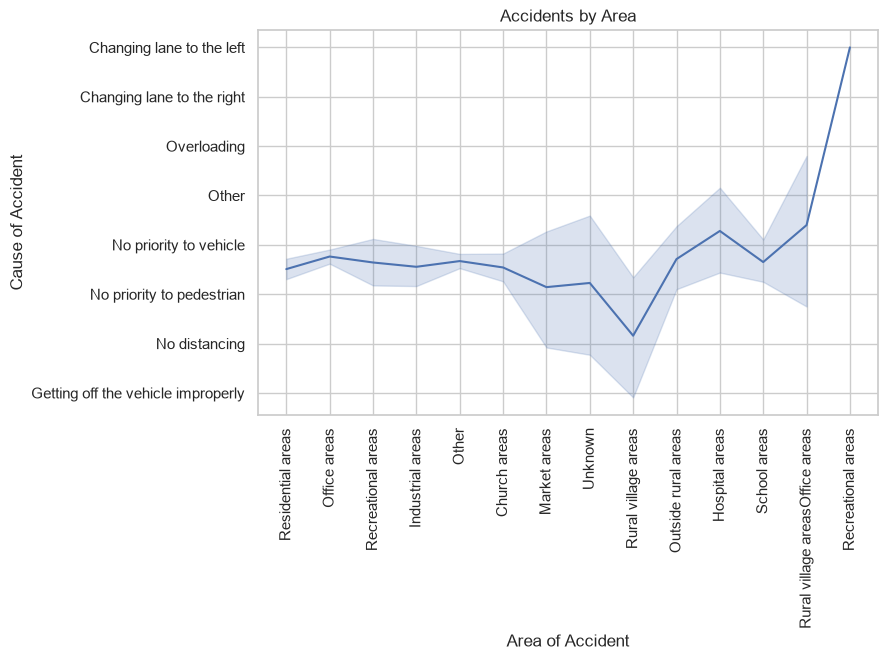

In [35]:
plt.figure(figsize=(8,5))
sns.lineplot(x="Area_accident_occured", y="Cause_of_accident", data=df, palette="Greens_r")
plt.title("Accidents by Area")
plt.xticks(rotation=90)
plt.ylabel("Cause of Accident")
plt.xlabel("Area of Accident")
plt.show()

C:\Users\akshi\AppData\Local\Temp\ipykernel_21048\336625211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Road_surface_conditions", width=0.5, data=df, palette="Blues_r")


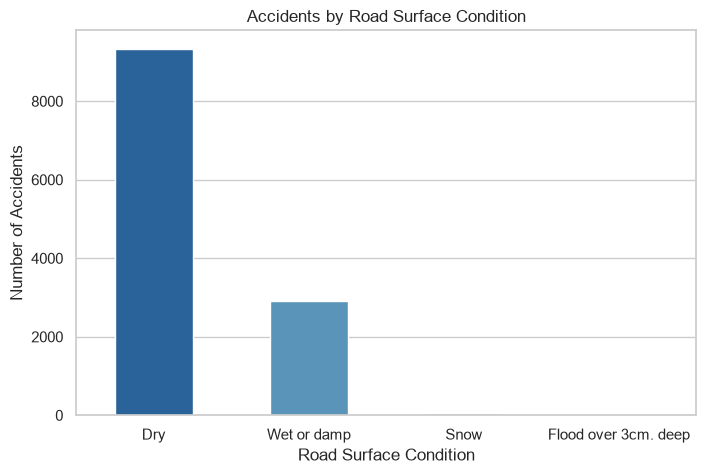

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="Road_surface_conditions", width=0.5, data=df, palette="Blues_r")
plt.title("Accidents by Road Surface Condition")
plt.xlabel("Road Surface Condition")
plt.ylabel("Number of Accidents")
plt.show()

<Figure size 600x400 with 0 Axes>

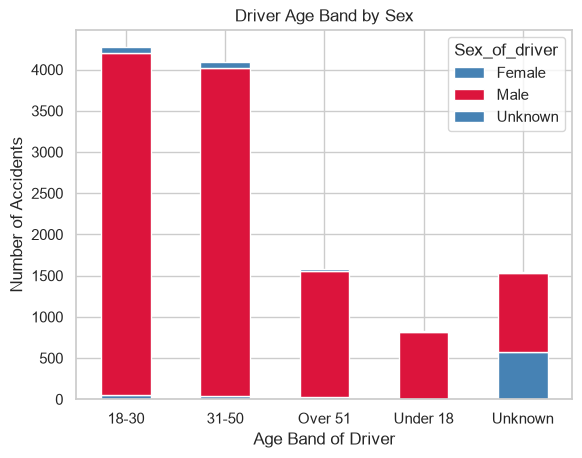

In [ ]:
plt.figure(figsize=(6,4))
pd.crosstab(df["Age_band_of_driver"], df["Sex_of_driver"]).plot(kind="bar", stacked=True, color=["steelblue", "crimson"])
plt.title("Driver Age Band by Sex")
plt.ylabel("Number of Accidents")
plt.xlabel("Age Band of Driver")
plt.xticks(rotation=00)
plt.show()

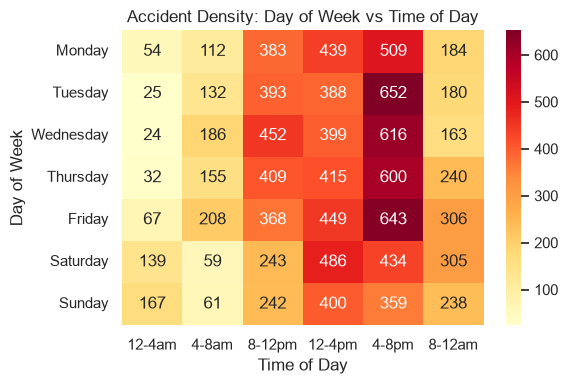

In [ ]:
plt.figure(figsize=(6,4))
pivot = pd.crosstab(df["Day_of_week"], df["time_bucket"]).reindex(index=day_order, columns=time_order)
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Accident Density: Day of Week vs Time of Day")
plt.tight_layout()
plt.xlabel("Time of Day")
plt.ylabel("Day of Week")
plt.show()

C:\Users\akshi\AppData\Local\Temp\ipykernel_21048\3095781550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Type_of_collision", data=df, order=df["Type_of_collision"].value_counts().index, palette="Reds_r")


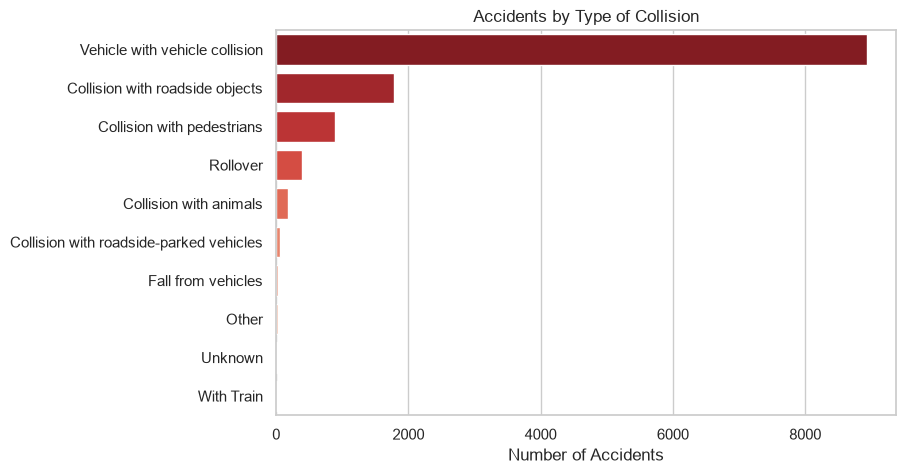

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y="Type_of_collision", data=df, order=df["Type_of_collision"].value_counts().index, palette="Reds_r")
plt.title("Accidents by Type of Collision")
plt.xlabel("Number of Accidents")
plt.ylabel("")
plt.show()

C:\Users\akshi\AppData\Local\Temp\ipykernel_21048\847324289.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Driving_experience", data=df, order=exp_order, palette="YlOrRd")


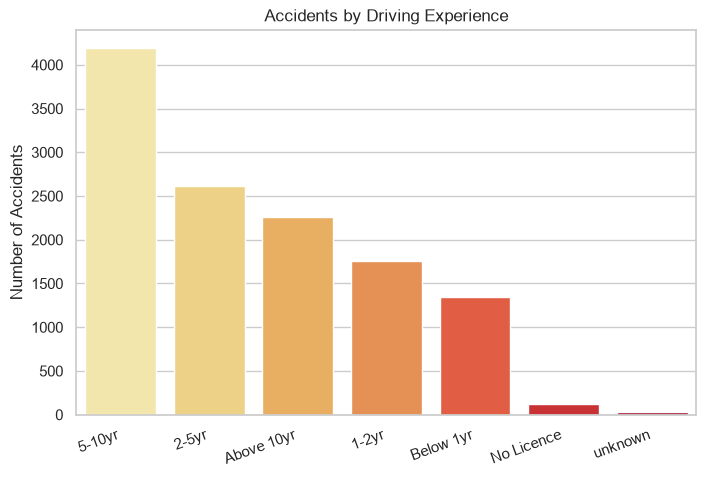

In [ ]:

plt.figure(figsize=(8,5))
exp_order = df["Driving_experience"].value_counts().index
sns.countplot(x="Driving_experience", data=df, order=exp_order, palette="YlOrRd")
plt.title("Accidents by Driving Experience")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Number of Accidents")
plt.xlabel("")
plt.show()

C:\Users\akshi\AppData\Local\Temp\ipykernel_21048\944023792.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Types_of_Junction", data=df, order=df["Types_of_Junction"].value_counts().index, palette="Blues_r")


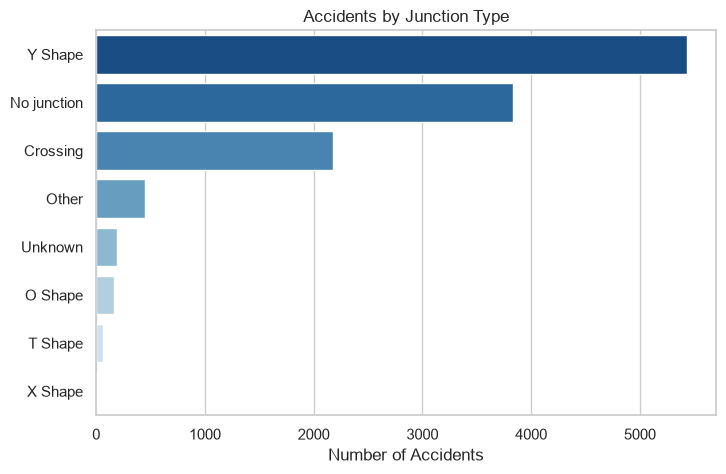

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y="Types_of_Junction", data=df, order=df["Types_of_Junction"].value_counts().index, palette="Blues_r")
plt.title("Accidents by Junction Type")
plt.xlabel("Number of Accidents")
plt.ylabel("")
plt.show()

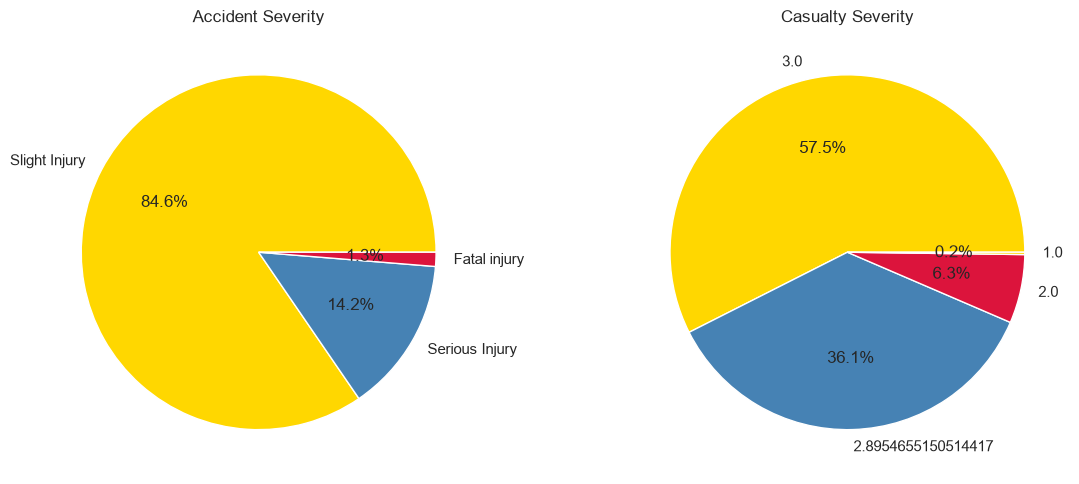

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

df["Accident_severity"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["gold","steelblue","crimson"], ax=axes[0])
axes[0].set_title("Accident Severity")
axes[0].set_ylabel("")

df["Casualty_severity"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["gold","steelblue","crimson"], ax=axes[1])
axes[1].set_title("Casualty Severity")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

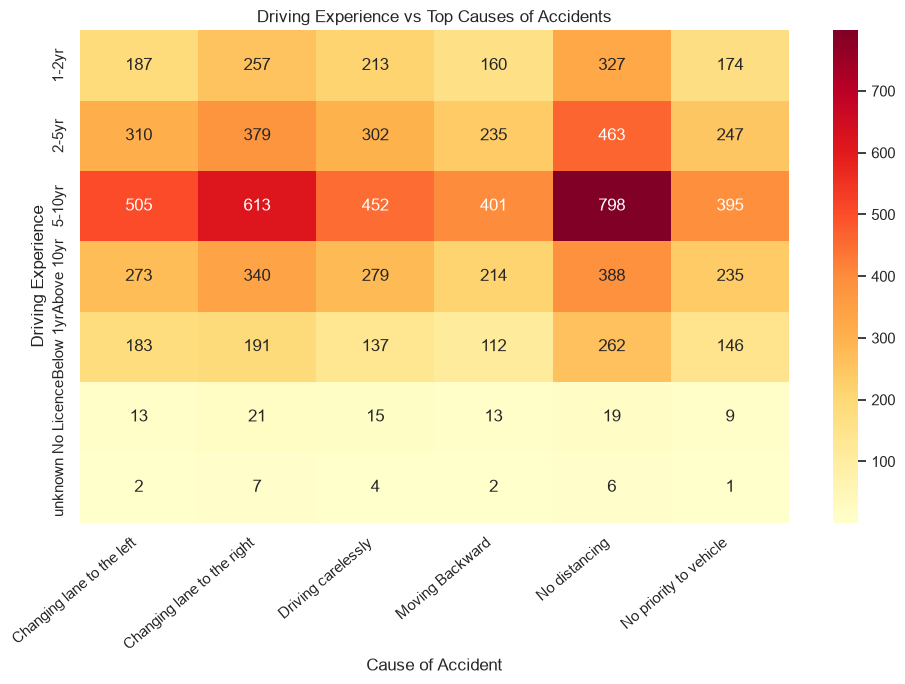

In [ ]:
plt.figure(figsize=(10,7))
top_causes = df["Cause_of_accident"].value_counts().head(6).index
subset = df[df["Cause_of_accident"].isin(top_causes)]

pivot = pd.crosstab(subset["Driving_experience"], subset["Cause_of_accident"])
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Driving Experience vs Top Causes of Accidents")
plt.ylabel("Driving Experience")
plt.xlabel("Cause of Accident")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()


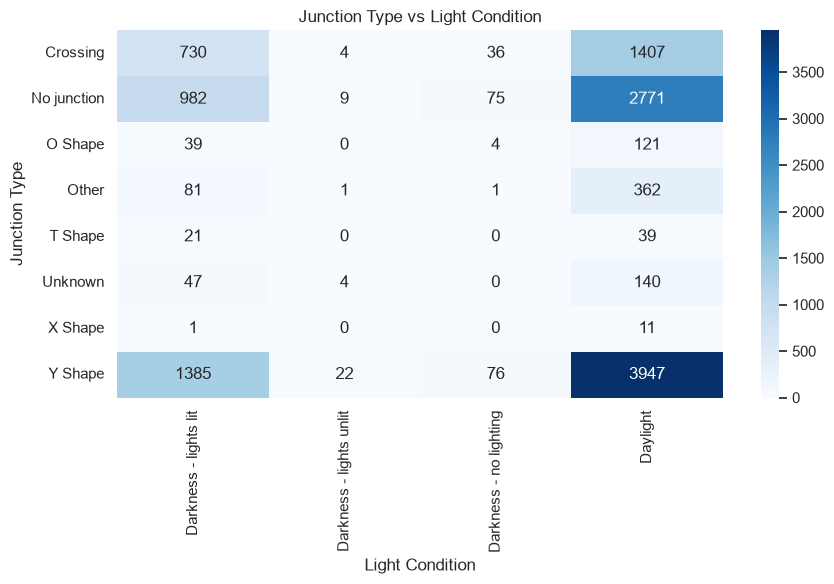

In [ ]:
plt.figure(figsize=(9,6))
pivot2 = pd.crosstab(df["Types_of_Junction"], df["Light_conditions"])
sns.heatmap(pivot2, annot=True, fmt="d", cmap="Blues")
plt.title("Junction Type vs Light Condition")
plt.ylabel("Junction Type")
plt.xlabel("Light Condition")
plt.tight_layout()
plt.show()

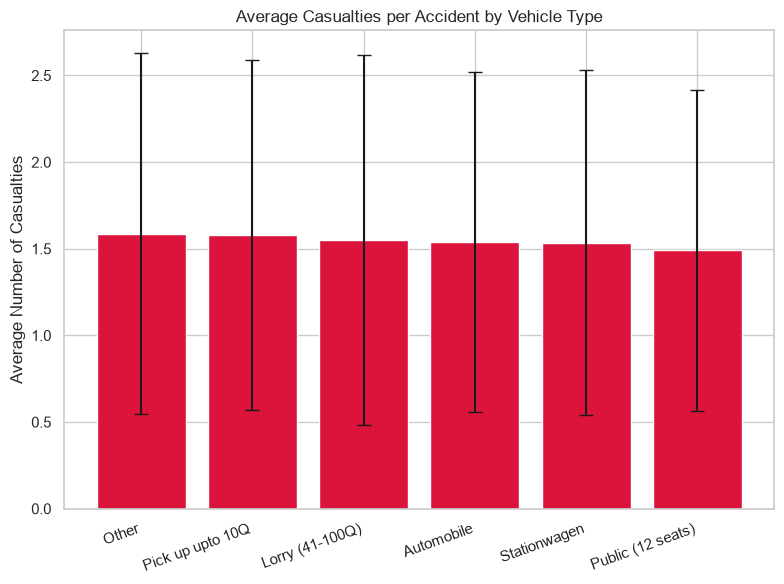

In [ ]:
plt.figure(figsize=(8,6))
top_vehicles = df["Type_of_vehicle"].value_counts().head(6).index
subset = df[df["Type_of_vehicle"].isin(top_vehicles)]

summary = subset.groupby("Type_of_vehicle")["Number_of_casualties"].agg(["mean", "std"]).sort_values("mean", ascending=False)

plt.bar(summary.index, summary["mean"], yerr=summary["std"], capsize=5, color="crimson", edgecolor="white")
plt.title("Average Casualties per Accident by Vehicle Type")
plt.xticks(rotation=20, ha="right")
plt.xlabel("")
plt.ylabel("Average Number of Casualties")
plt.tight_layout()
plt.show()